In [1]:
import scMPRAforge as scm
from dask.distributed import Client, LocalCluster
from pathlib import Path
import pandas as pd

2025-11-12 12:22:20.930189: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-12 12:22:21.928852: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /vast/palmer/apps/avx2/software/code-server/4.91.1/lib:/vast/palmer/apps/avx2/software/gettext/0.22.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libiconv/1.17-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/ncurses/6.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/XZ/5.4.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/expat/2.6.2-GCCcore-13.3.0/lib:/vast/palmer/apps/av

In [2]:
DATA_ROOT=Path("/gpfs/gibbs/pi/reilly/tabula_data")
path=DATA_ROOT/"simulated"
name="shendure_calibrated_sim_with_orthos_20251008"

In [3]:
cluster = LocalCluster(memory_limit='48G')
client = Client(cluster)

In [4]:
simu_obj=scm.de_novo_simulation.load(client,path=path,name=name)

In [5]:
ex_ground_truth=simu_obj.ground_truth

In [8]:
def load_result(root: Path, hypothesis: str, test: str, replicate: int) -> pd.DataFrame:
    """Load a TSV result from the given directory structure."""
    path = root / hypothesis / test / str(replicate)
    if not path.exists():
        raise FileNotFoundError(f"No such file: {path}")
    return pd.read_csv(path, sep='\t')

In [9]:
def merge_in_ground_truth(results,ground_truth):    
        merged=results.merge(ground_truth,
            left_on=["comparison_CRE","comparison_cell_type"],
            right_on=["cre_id","cell_type"]
        )
        
        merged=merged.drop(columns=["cre_id","cell_type"])
        merged=merged.rename({"true_mean":"comparison_truth"},axis=1)

        #merge in `reference` ground truth
        merged=merged.merge(ground_truth,
            left_on=["reference_CRE","reference_cell_type"],
            right_on=["cre_id","cell_type"]
        )
        merged=merged.drop(columns=["cre_id","cell_type"])
        merged=merged.rename({"true_mean":"reference_truth"},axis=1)

        #ground truth effect size
        merged["gt_effect_size"]=merged["comparison_truth"]/merged["reference_truth"]
        #ground truth null hypothesis that the CREs are the same : true or false?
        merged["gt_null"]=abs(merged["gt_effect_size"]-1)<1e-8

        merged["reject_null"]=merged["bh_p"]<0.05

        #godawful hack
        #merged=merged.dropna(subset=["p_value"])

        return merged

In [10]:
ground_truth=simu_obj.ground_truth

records = []

for test in ["mwu", "wald"]:
    for hypothesis_set in ["hs_all_cre", "hs_all_ct"]:
        for replicate in range(5):
            ex = load_result(root=path/name/"results",
                                hypothesis=hypothesis_set,
                                test=test,
                                replicate=replicate)
            ex_merged = merge_in_ground_truth(results=ex,
                                                ground_truth=ex_ground_truth)
            ct = pd.crosstab(ex_merged["gt_null"], ex_merged["reject_null"])
            # Flatten the crosstab into a dict of counts
            for (gt, reject), count in ct.stack().items():
                records.append({
                    "test": test,
                    "hypothesis_set": hypothesis_set,
                    "replicate": replicate,
                    "gt_null": gt,
                    "reject_null": reject,
                    "count": count
                })

df = pd.DataFrame(records)
summary = (df.groupby(["test", "hypothesis_set", "gt_null", "reject_null"])
                ["count"]
                .agg(["mean", "std", "sum", "count"])
                .reset_index())

In [15]:
summary

,test,hypothesis_set,gt_null,reject_null,mean,std,sum,count
0,mwu,hs_all_cre,False,False,186.0,8.455767,930,5
1,mwu,hs_all_cre,False,True,1060.0,8.455767,5300,5
2,mwu,hs_all_ct,False,False,206.8,10.639549,1034,5
3,mwu,hs_all_ct,False,True,1245.2,10.639549,6226,5
4,wald,hs_all_cre,False,False,173.8,8.786353,869,5
5,wald,hs_all_cre,False,True,1072.2,8.786353,5361,5
6,wald,hs_all_ct,False,False,384.8,69.969279,1924,5
7,wald,hs_all_ct,False,True,1067.2,69.969279,5336,5


In [16]:
records = []
for test in ["mwu", "wald"]:
    for hypothesis_set in ["hs_all_cre", "hs_all_ct"]:
        correct_fracs = []
        for replicate in range(5):
            ex = load_result(root=path/name/"results",
                                hypothesis=hypothesis_set,
                                test=test,
                                replicate=replicate)
            ex_merged = merge_in_ground_truth(results=ex,
                                                ground_truth=ex_ground_truth)

            # since gt_null is always False, "correct" means reject_null == True
            frac_correct = (ex_merged["reject_null"] == True).mean()
            correct_fracs.append(frac_correct)

        records.append({
            "test": test,
            "hypothesis_set": hypothesis_set,
            "mean_fraction_correct": pd.Series(correct_fracs).mean(),
            "std_fraction_correct": pd.Series(correct_fracs).std(),
        })

pd.DataFrame(records)

,test,hypothesis_set,mean_fraction_correct,std_fraction_correct
0,mwu,hs_all_cre,0.850722,0.006786
1,mwu,hs_all_ct,0.857576,0.007328
2,wald,hs_all_cre,0.860514,0.007052
3,wald,hs_all_ct,0.734986,0.048188


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_p_vs_effect(hypothesis_set, test, replicate):
    ex = load_result(root=path/name/"results",
                     hypothesis=hypothesis_set,
                     test=test,
                     replicate=replicate)
    df = merge_in_ground_truth(results=ex, ground_truth=ex_ground_truth)

    # compute color by log10(max of comparison_truth and reference_truth)
    df["log_max_activity"] = np.log10(np.maximum(df["comparison_truth"], df["reference_truth"]).clip(lower=1e-12))

    # use a reversed warm colormap (small = red/yellow, large = blue)
    sns.scatterplot(data=df, x="gt_effect_size", y="p_value", hue="log_max_activity",
                    palette="inferno_r", alpha=0.6)

    plt.xscale("log")
    plt.yscale("log")
    plt.xlim(1e-2, 1e4)
    plt.ylim(1e1, 1e-310)

    plt.xlabel("Ground Truth Effect Size (log scale)")
    plt.ylabel("p-value (log scale)")
    plt.legend(title="log10(Max Activity)")
    plt.title(f"p-value vs Ground Truth Effect Size\n(test={test}, hypothesis_set={hypothesis_set}, replicate={replicate})")
    plt.tight_layout()
    plt.show()


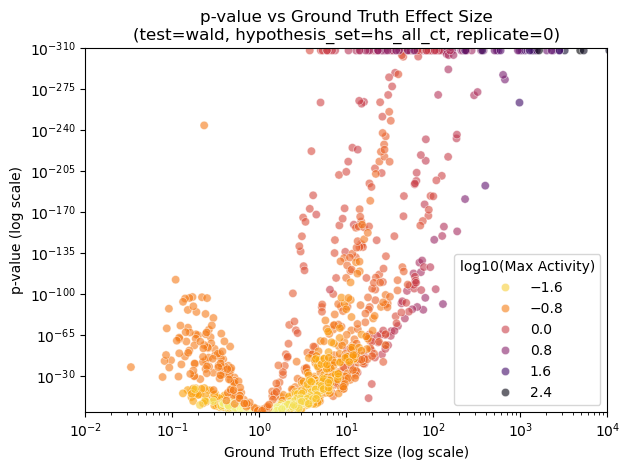

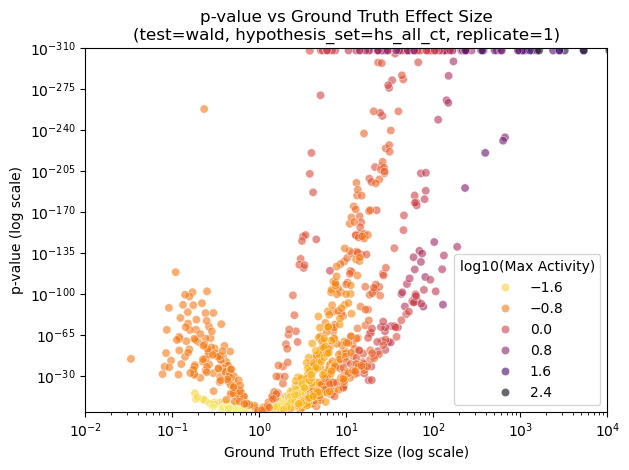

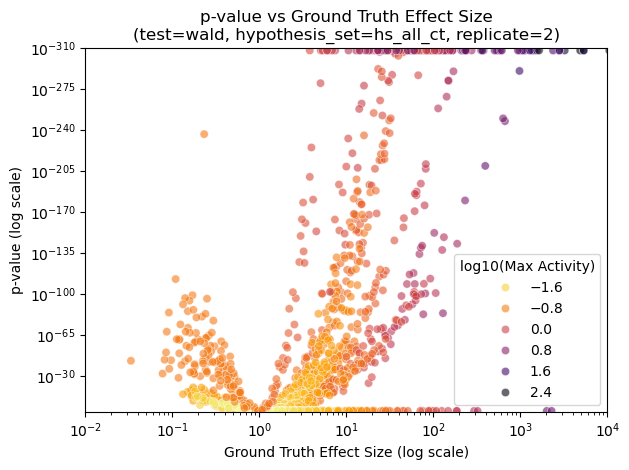

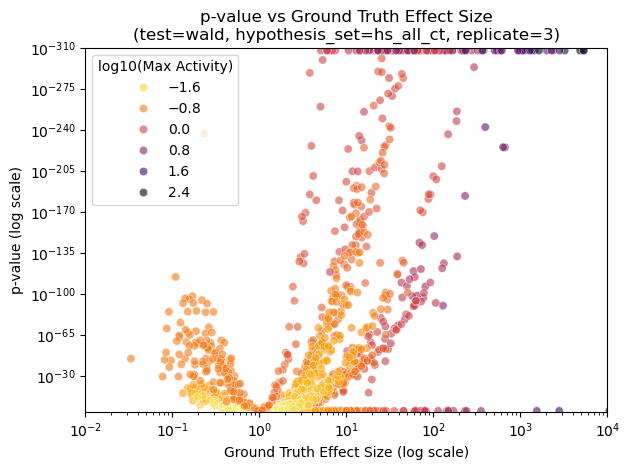

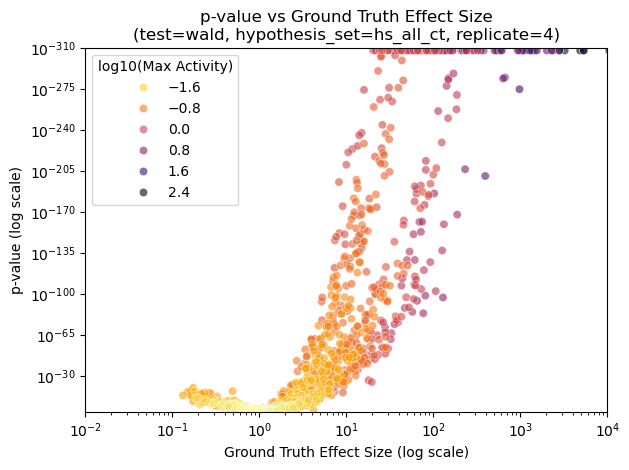

In [18]:
for replicate in range(5):
    plot_p_vs_effect(hypothesis_set="hs_all_ct",test="wald",replicate=replicate)

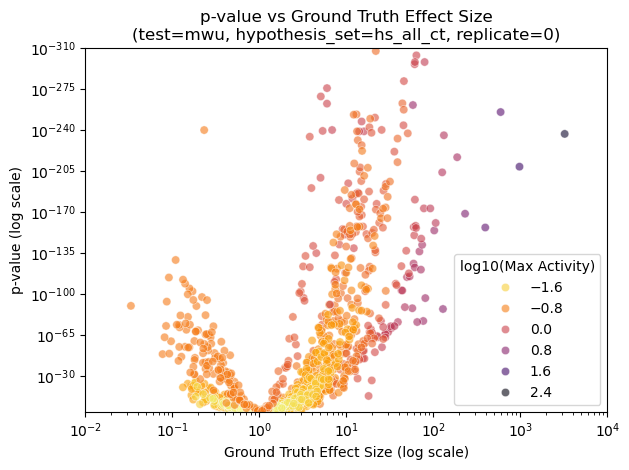

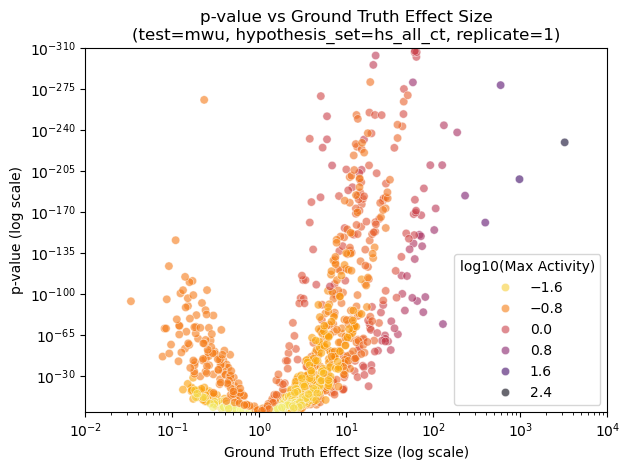

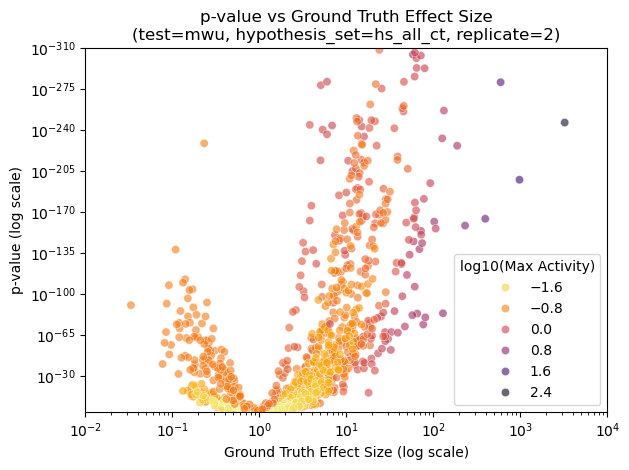

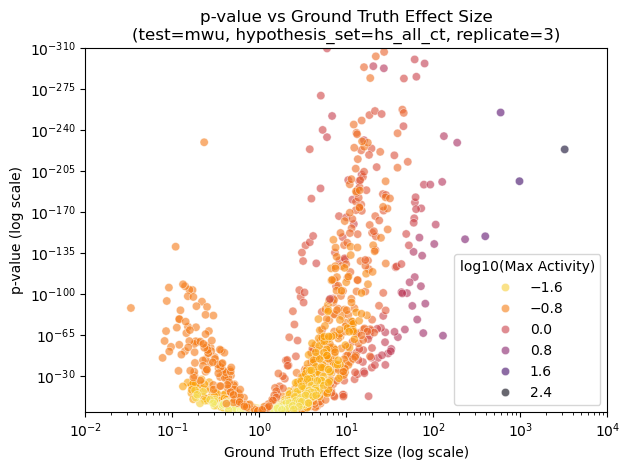

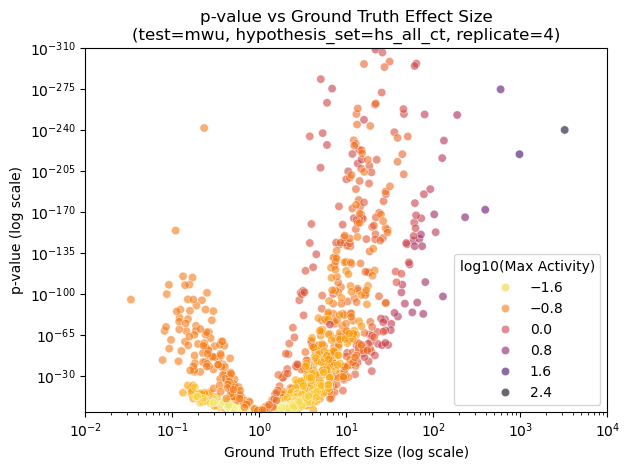

In [19]:
for replicate in range(5):
    plot_p_vs_effect(hypothesis_set="hs_all_ct",test="mwu",replicate=replicate)

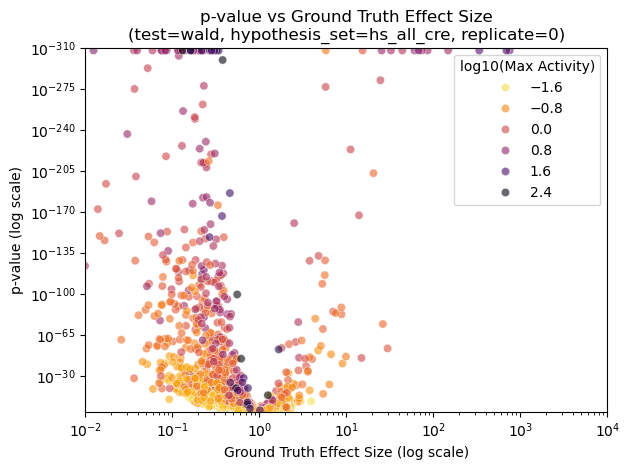

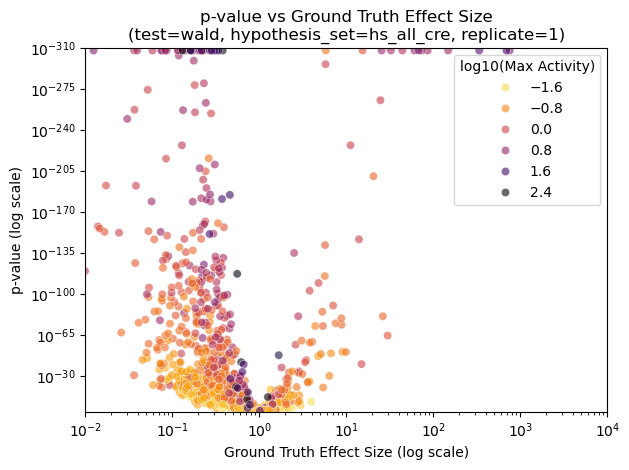

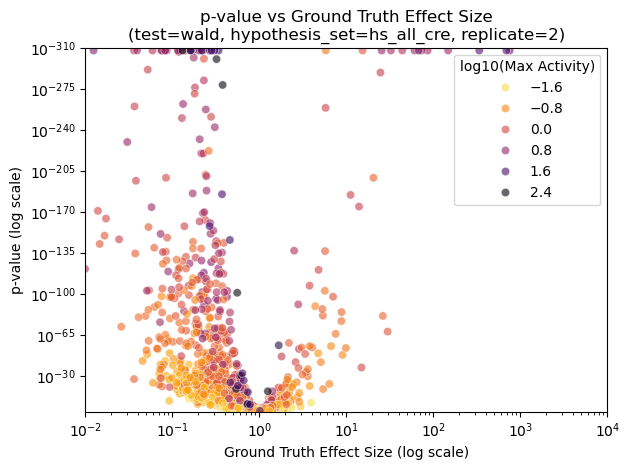

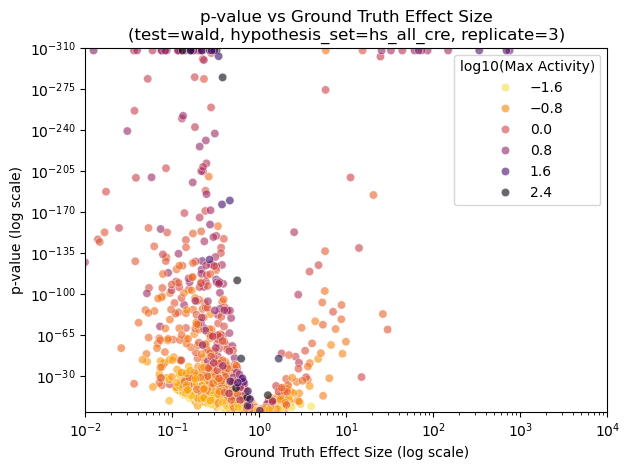

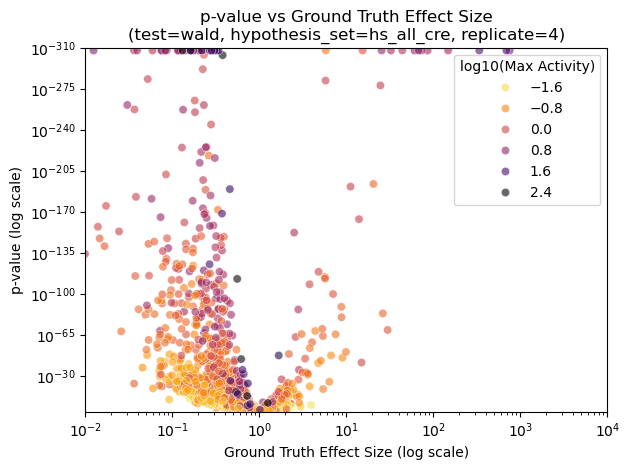

In [20]:
for replicate in range(5):
    plot_p_vs_effect(hypothesis_set="hs_all_cre",test="wald",replicate=replicate)

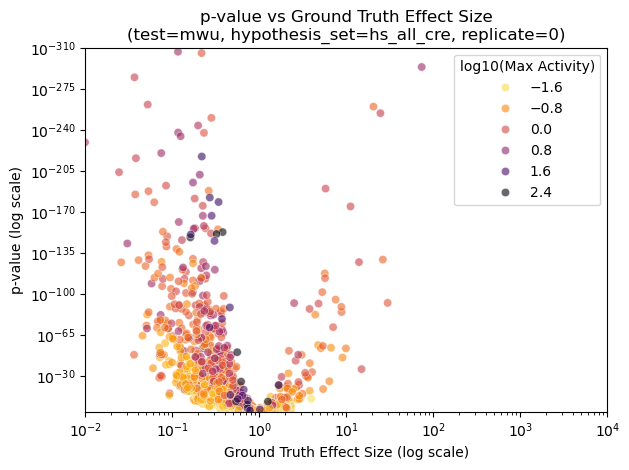

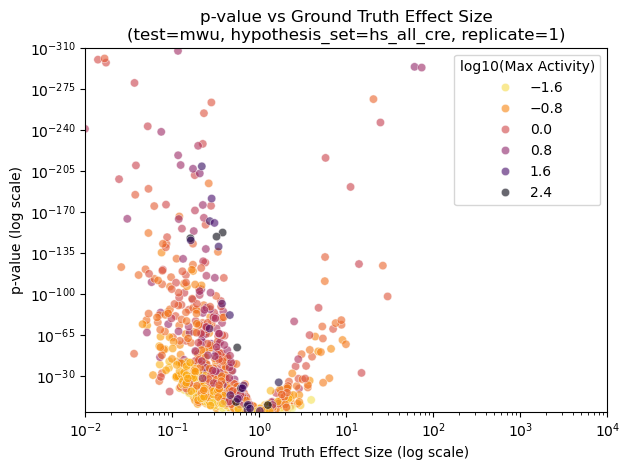

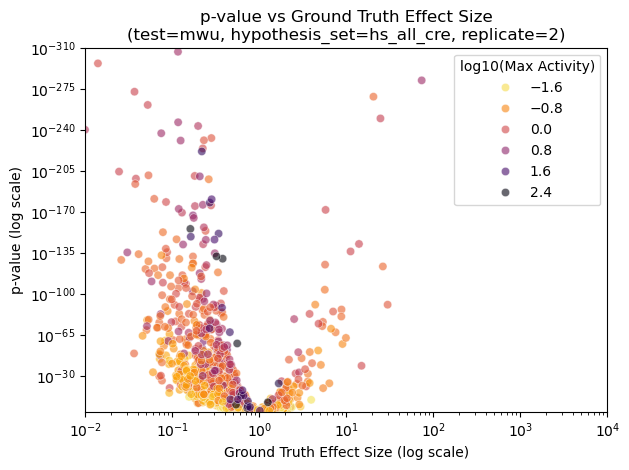

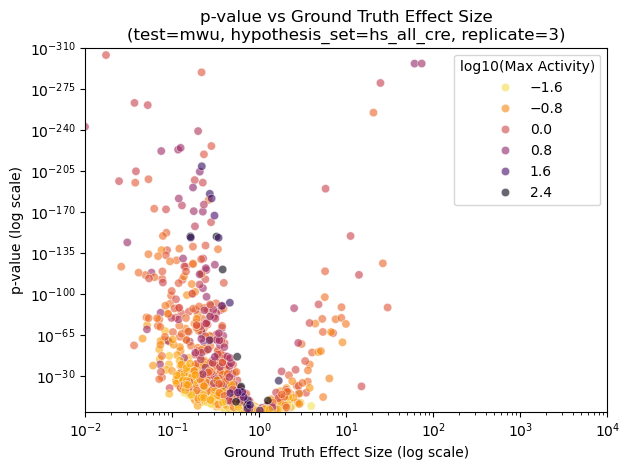

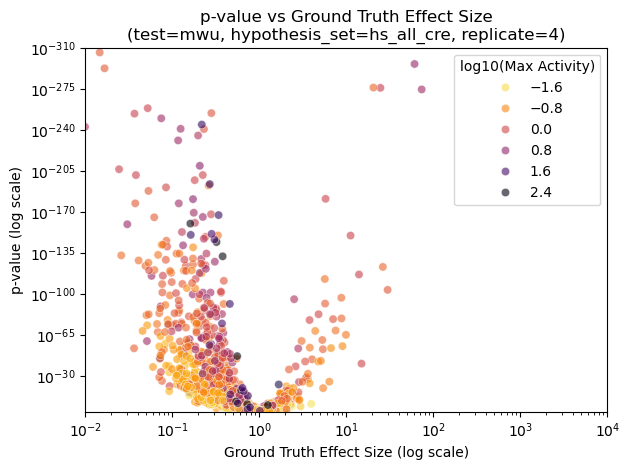

In [21]:
for replicate in range(5):
    plot_p_vs_effect(hypothesis_set="hs_all_cre",test="mwu",replicate=replicate)

In [54]:
ex = load_result(root=path/name/"results",
                     hypothesis="hs_all_ct",
                     test="wald",
                     replicate=2)
df = merge_in_ground_truth(results=ex, ground_truth=ex_ground_truth)

In [55]:
df[df.isna().any(axis=1)]

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,wald_debug,test_type,bh_p,comparison_truth,reference_truth,gt_effect_size,gt_null,reject_null


In [51]:
df[df.comparison_cell_type=='SurfaceEctoderm']

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,wald_debug,test_type,bh_p,comparison_truth,reference_truth,gt_effect_size,gt_null,reject_null
1108,Col1a1_chr11_15259,SurfaceEctoderm,reference,SurfaceEctoderm,emvar_screen,-0.144795,0.884873,4.592991e-54,False,ill-conditioned cov_nb (cond=2.08e+12); H=np.a...,wald,0.897995,0.017466,0.007186,2.430400,False,False
1109,Lamb1_chr12_2238,SurfaceEctoderm,reference,SurfaceEctoderm,emvar_screen,-0.143747,0.885700,1.116738e-53,False,ill-conditioned cov_nb (cond=2.08e+12); H=np.a...,wald,0.897995,0.032681,0.007186,4.547713,False,False
1110,Sox17_chr1_58,SurfaceEctoderm,reference,SurfaceEctoderm,emvar_screen,-0.145016,0.884698,3.806417e-54,False,ill-conditioned cov_nb (cond=2.08e+12); H=np.a...,wald,0.897995,0.009306,0.007186,1.294979,False,False
1111,Sparc_chr11_7234,SurfaceEctoderm,reference,SurfaceEctoderm,emvar_screen,-0.140146,0.888545,2.369328e-52,False,ill-conditioned cov_nb (cond=2.08e+12); H=np.a...,wald,0.897995,0.901061,0.007186,125.386010,False,False
1112,Col1a1_chr11_15307,SurfaceEctoderm,reference,SurfaceEctoderm,emvar_screen,-0.141569,0.887421,7.086710e-53,False,ill-conditioned cov_nb (cond=2.08e+12); H=np.a...,wald,0.897995,0.279695,0.007186,38.920559,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1241,Gata4_chr14_5677,SurfaceEctoderm,reference,SurfaceEctoderm,emvar_screen,-0.141287,0.887643,8.999818e-53,False,ill-conditioned cov_nb (cond=2.08e+12); H=np.a...,wald,0.897995,0.366307,0.007186,50.972941,False,False
1242,Col1a1_chr11_15276,SurfaceEctoderm,reference,SurfaceEctoderm,emvar_screen,-0.142778,0.886466,2.540957e-53,False,ill-conditioned cov_nb (cond=2.08e+12); H=np.a...,wald,0.897995,0.107705,0.007186,14.987585,False,False
1243,Lamc1_chr1_12127,SurfaceEctoderm,reference,SurfaceEctoderm,emvar_screen,-0.144269,0.885288,7.172239e-54,False,ill-conditioned cov_nb (cond=2.08e+12); H=np.a...,wald,0.897995,0.026493,0.007186,3.686638,False,False
1244,Sox17_chr1_65,SurfaceEctoderm,reference,SurfaceEctoderm,emvar_screen,-0.144909,0.884783,4.169446e-54,False,ill-conditioned cov_nb (cond=2.08e+12); H=np.a...,wald,0.897995,0.017960,0.007186,2.499170,False,False


In [47]:
ex2 = load_result(root=path/name/"results",
                     hypothesis="hs_all_cre",
                     test="wald",
                     replicate=1)
df2 = merge_in_ground_truth(results=ex2, ground_truth=ex_ground_truth)

In [48]:
df2[df2.isna().any(axis=1)]

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,wald_debug,test_type,bh_p,comparison_truth,reference_truth,gt_effect_size,gt_null,reject_null
846,Sox17_chr1_60,ExEndodermParietal,Sox17_chr1_60,reference,cell_specificity,NaN,NaN,NaN,False,no contrast term for ExEndodermParietal,wald,1.0,0.005472,0.05909,0.0926,False,False
1189,Txndc12_chr4_7969,ExEndodermParietal,Txndc12_chr4_7969,reference,cell_specificity,NaN,NaN,NaN,False,no contrast term for ExEndodermParietal,wald,1.0,0.154256,0.00000,inf,False,False


In [20]:
client.close()
cluster.close()